In [2]:
%matplotlib widget
import gsd.hoomd
import numpy as np 
import matplotlib.pyplot as plt


In [63]:
L=28
initparticle=1000



In [ ]:
locipos=[-31,39,-88,86,-121,134,-178,54]
for lo in locipos:
    if locipos>=0:
        lociindex=int(locipos*500/180)
    else:
        lociindex=1000+int(locipos*500/180)
lociindex

108

In [ ]:
avgloci1=np.zeros(2400,len(locipos))
avgloci2=np.zeros(2400,len(locipos))
maxiter=60
for iter in range(maxiter):
    print(f'\r{iter}',end='')
    file=gsd.hoomd.open(f'1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    timefile1=np.zeros(2400)
    loci108=np.zeros(2400)
    loci1216=np.zeros(2400)
    for frames in file:
        pos=frames.particles.position
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L

        timefile1[i]=i*50/100/1000
        R=frames.particles.N

        if locipos>=0:
            if R<=1000+2*lociindex+2:
                loci108[i]=(pos[lociindex][2]+(lenth-28))/lenth
                loci1216[i]=(pos[lociindex][2]+(lenth-28))/lenth
            if R>1000+2*lociindex+2:
                loci108[i]=(pos[lociindex][2]+(lenth-28))/lenth
                loci1216[i]=(pos[1000+2*lociindex][2]+(lenth-28))/lenth
        else:
            neglociindex=1000-lociindex
            if R<=1000+2*abs(neglociindex)+2:
                loci108[i]=(pos[lociindex][2]+(lenth-28))/lenth
                loci1216[i]=(pos[lociindex][2]+(lenth-28))/lenth
            if R>1000+2*abs(neglociindex)+2:
                loci108[i]=(pos[lociindex][2]+(lenth-28))/lenth
                loci1216[i]=(pos[1000+2*neglociindex+1][2]+(lenth-28))/lenth
        i=i+1
    avgloci1=avgloci1+loci108
    avgloci2=avgloci2+loci1216
avgloci1=avgloci1/maxiter
avgloci2=avgloci2/maxiter

59

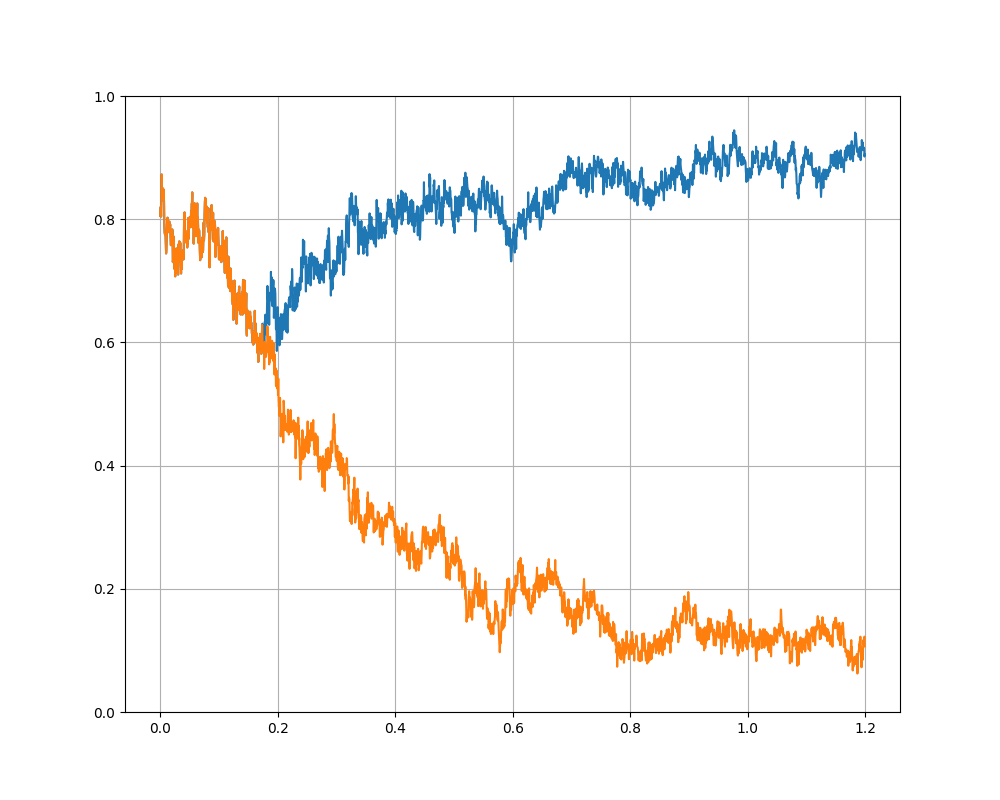

In [85]:
plt.figure(figsize=(10,8))

plt.ylim(0, 1)
plt.plot(timefile1,avgloci1)
plt.plot(timefile1,avgloci2)
plt.grid(True)

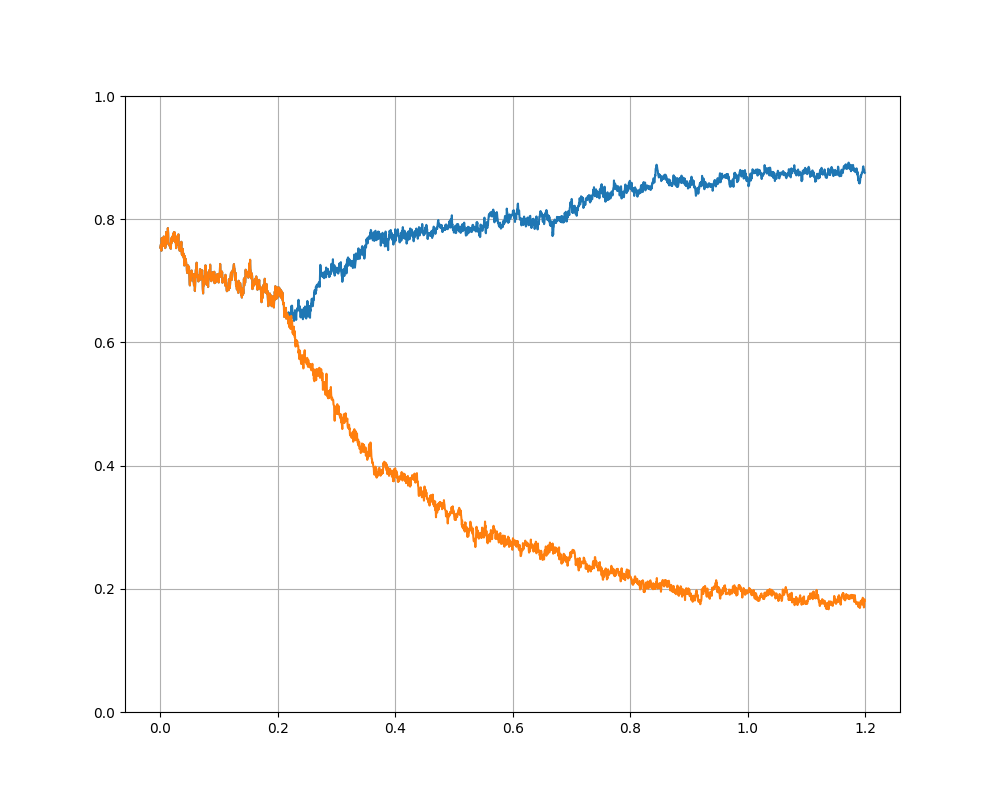

In [95]:
plt.figure(figsize=(10,8))
plt.ylim(0, 1)
plt.plot(timefile1,avgloci1)
plt.plot(timefile1,avgloci2)
plt.grid(True)

In [96]:
a=[[2,3],[3,5]]
b=[[3,3],[5,5]]
a+b

[[2, 3], [3, 5], [3, 3], [5, 5]]

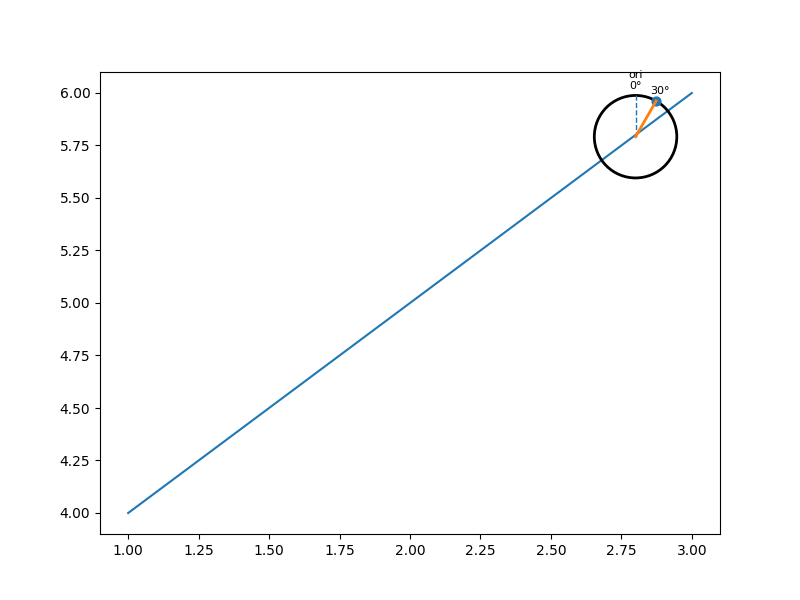

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(8,6))
ax.plot([1,2,3],[4,5,6])   # main plot

# theta_deg = locipos[j]   # can be positive or negative
theta_deg = 30
# convert angle:
# 0° at top, positive clockwise
theta = np.deg2rad(90 - theta_deg)

# inset
axins = inset_axes(ax, width="25%", height="25%", loc='upper right')

# draw circle
circle = plt.Circle((0, 0), 1, fill=False, linewidth=2)
axins.add_patch(circle)

# draw 0 degree reference line (top)
axins.plot([0, 0], [0, 1], '--', linewidth=1)
axins.text(0, 1.15, 'ori\n0°', fontsize=8, ha='center')

# point at locus angle
x = np.cos(theta)
y = np.sin(theta)

axins.plot([0, x], [0, y], linewidth=2)
axins.scatter(x, y, s=40)
axins.text(x*1.2, y*1.2, f'{theta_deg}°', fontsize=8, ha='center')

# formatting
axins.set_xlim(-1.4, 1.4)
axins.set_ylim(-1.4, 1.4)
axins.set_aspect('equal')
axins.axis('off')

plt.show()

2

/tmp/ipykernel_1281076/2891796530.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1281076/2891796530.py:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,8))


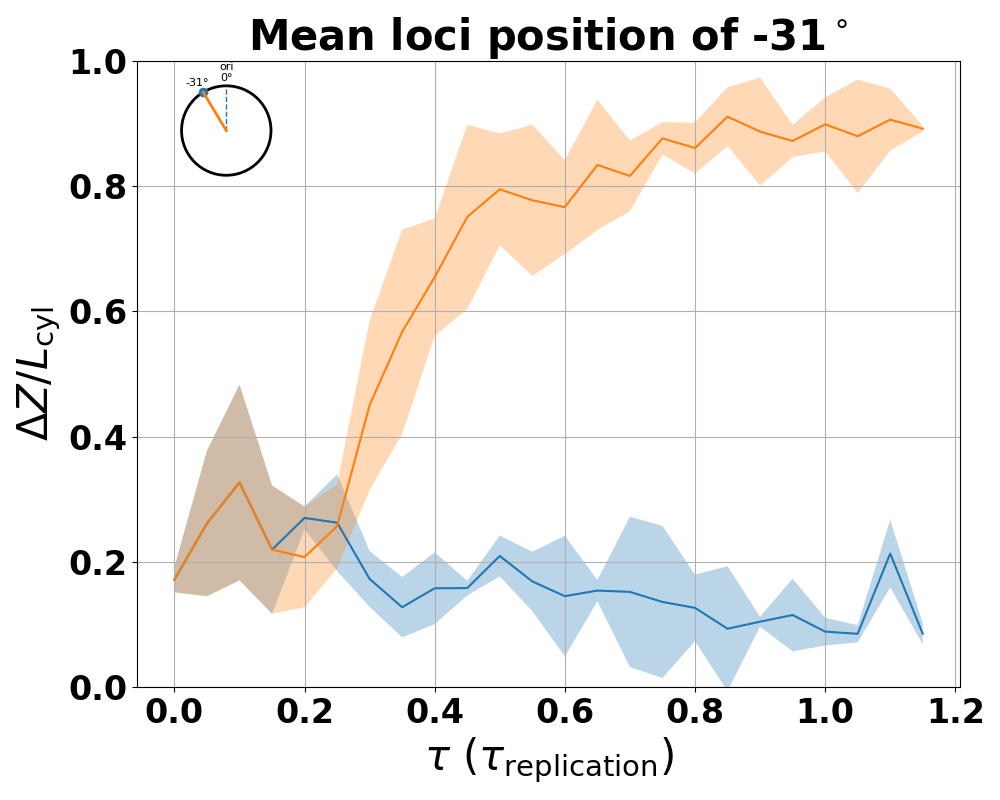

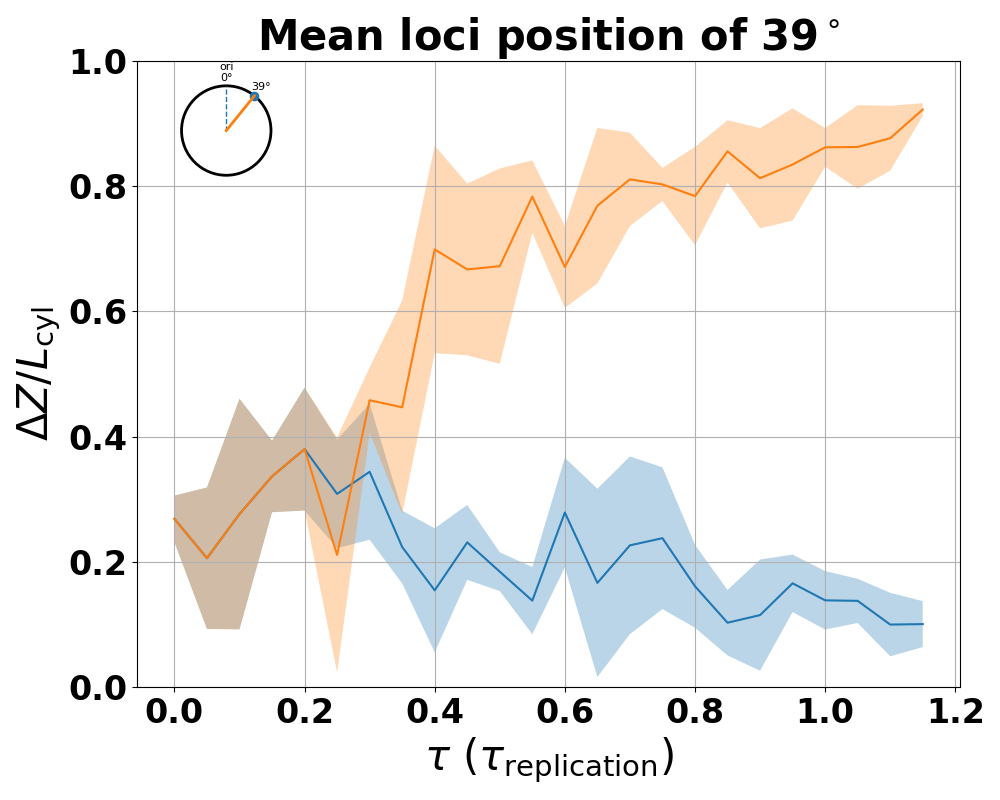

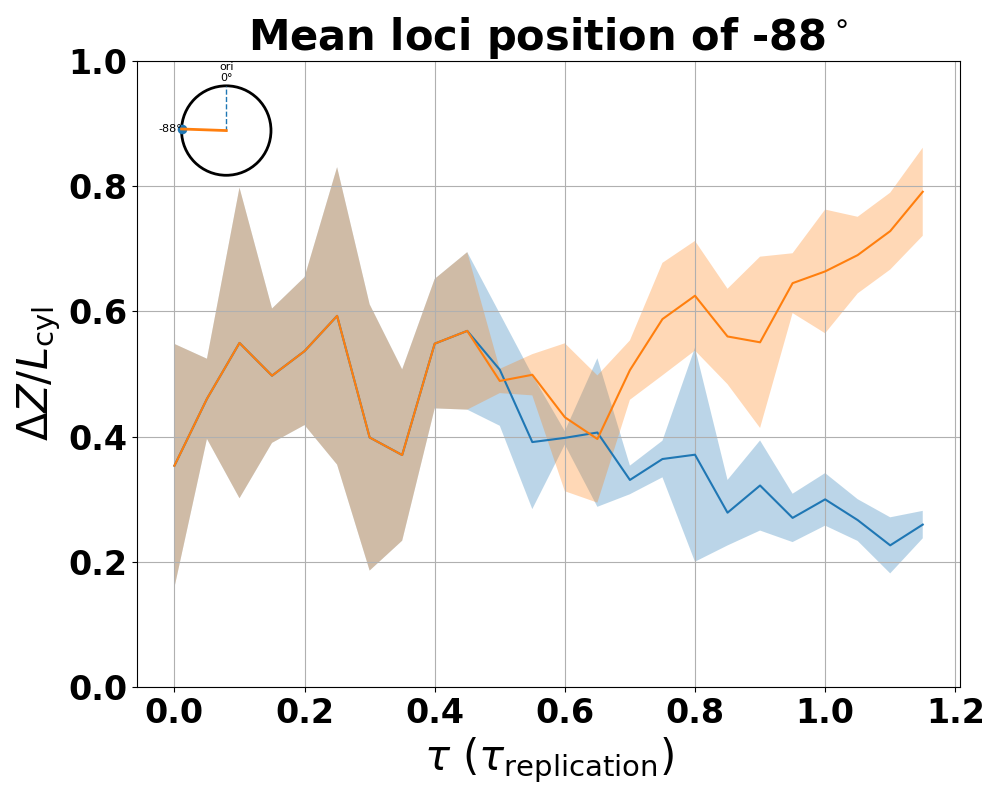

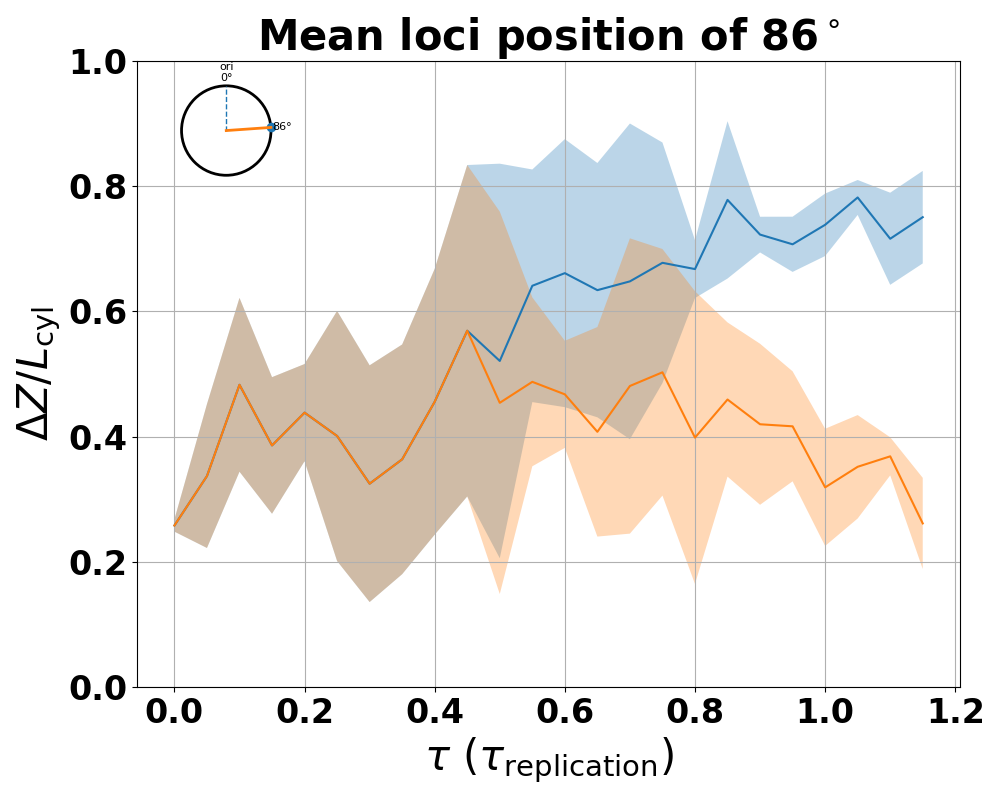

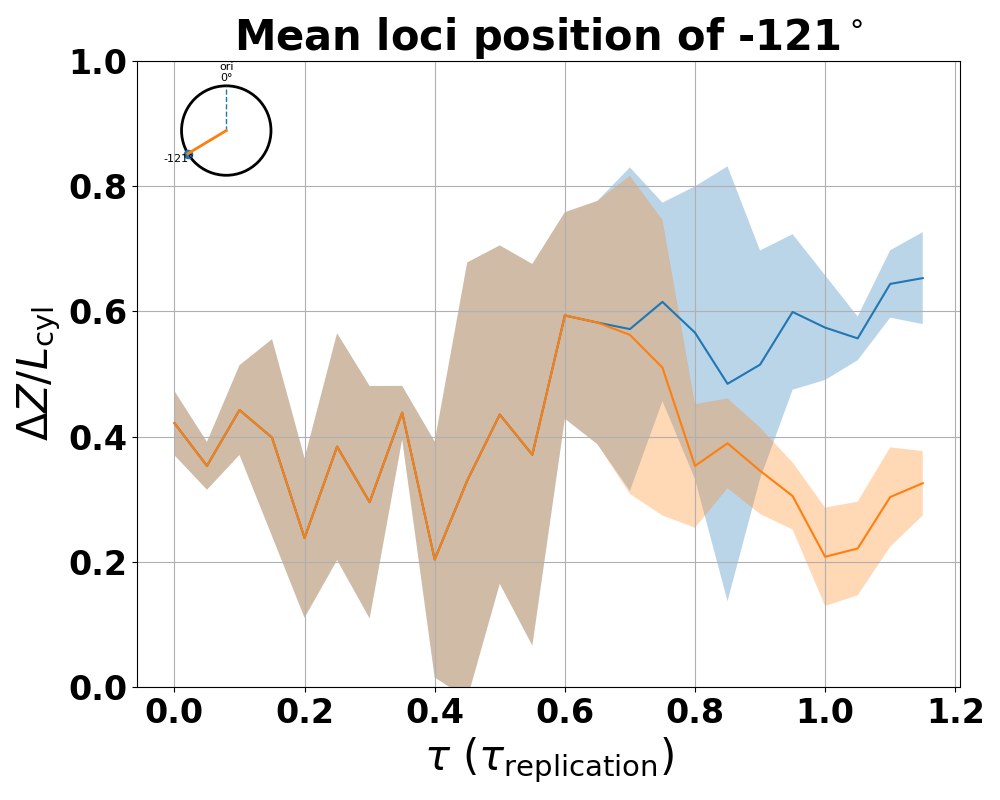

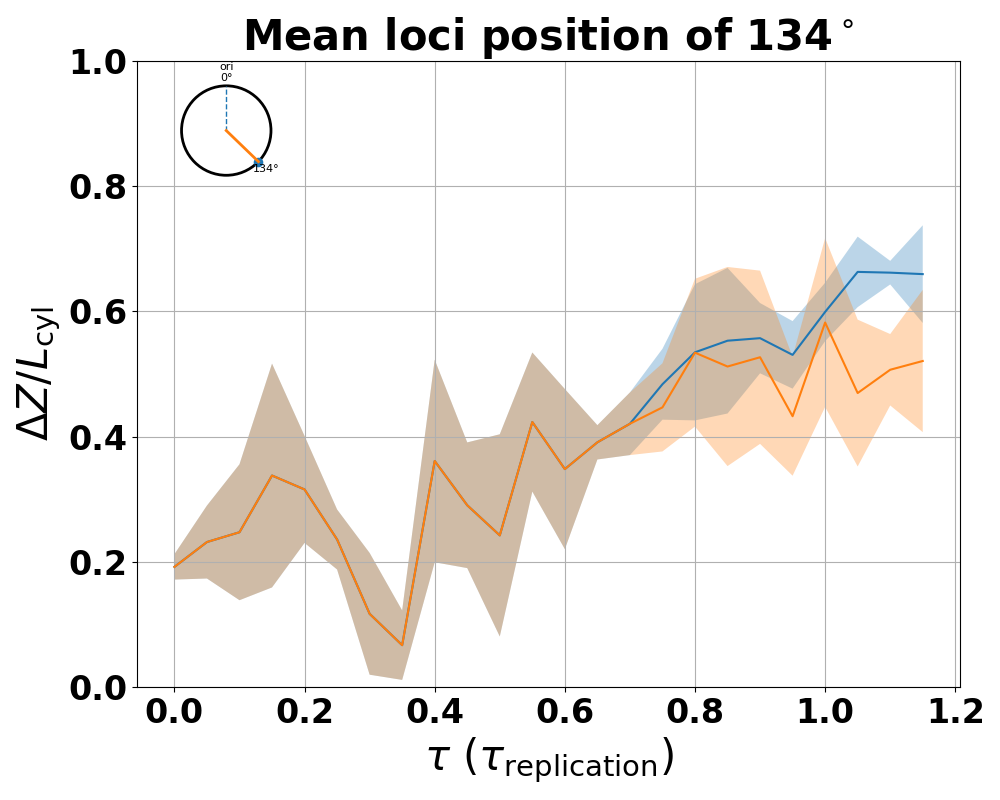

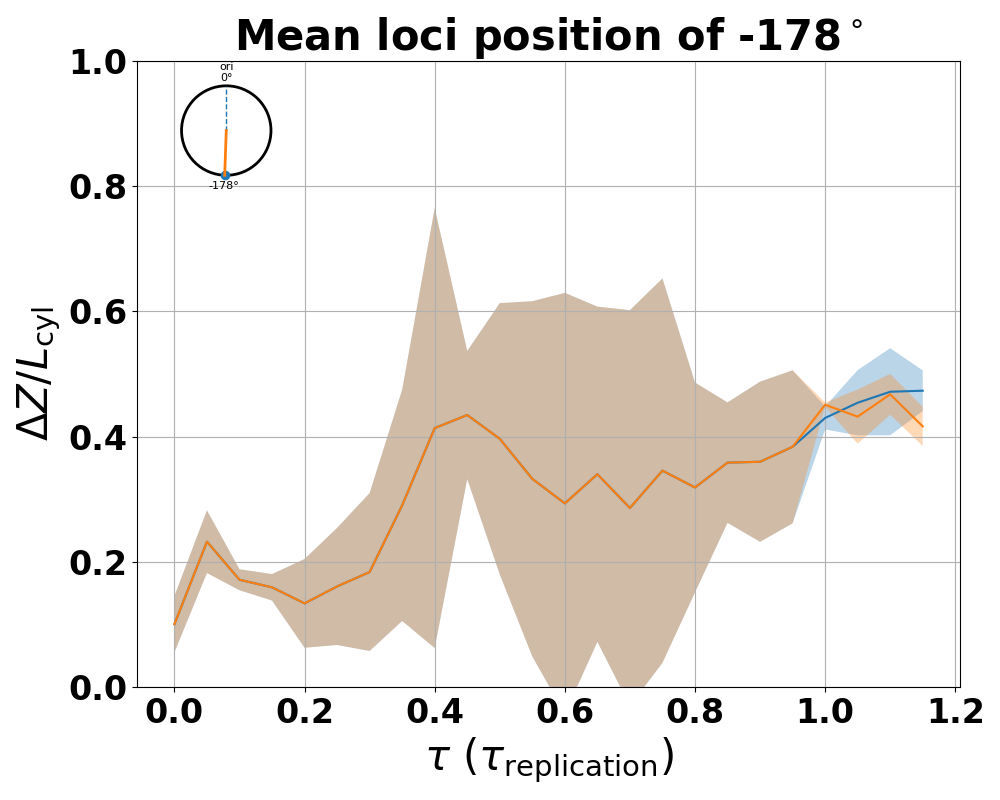

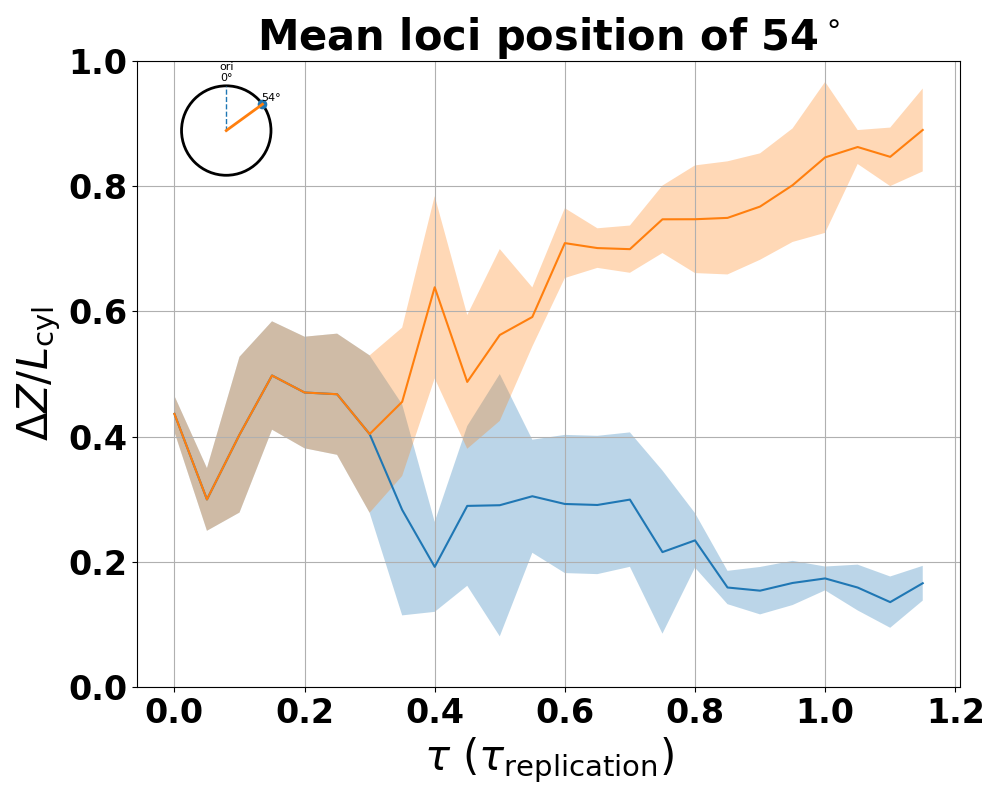

In [11]:
import gsd.hoomd
import numpy as np 
import matplotlib.pyplot as plt
import os

os.makedirs('1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru2/locitraj',exist_ok=True)

L=28
initparticle=1000
freq=100
locipos=[-31,39,-88,86,-121,134,-178,54]

ntime = int(2400/freq)
maxiter=3

lociindex=np.zeros(len(locipos))
for i,lo in enumerate(locipos):
    if lo>=0:
        lociindex[i]=int(lo*500/180)
    else:
        lociindex[i]=1000+int(lo*500/180)

# store all iterations
all_loci1=np.zeros((maxiter,len(locipos),ntime))
all_loci2=np.zeros((maxiter,len(locipos),ntime))
count=0
for iter in range(maxiter):
    print(f'\r{iter}',end='')

    
    try:
        file=gsd.hoomd.open(f'1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    except FileNotFoundError:
        print(f"Warning: File for run {i} not found. Skipping.")
        continue
    i=0
    k=0
    count=count+1
    timefile1=np.zeros(ntime)
    loci1=np.zeros((len(locipos),ntime))
    loci2=np.zeros((len(locipos),ntime))

    for frames in file:

        if (k%freq==0):

            pos=frames.particles.position
            time=int(int(k/4)-1)

            lenth=L
            if time>=0 and time<=(initparticle/2):
                kk = (np.log(2*L) - np.log(L)) / (initparticle/2)
                lenth=L*np.exp(kk*time)

            if time>initparticle/2:
                lenth=2*L

            timefile1[i]=k*50/100/1000
            R=frames.particles.N

            for j in range(len(locipos)):

                if locipos[j]>=0:

                    if R<=1000+2*lociindex[j]+2:
                        loci1[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth
                        loci2[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth

                    if R>1000+2*lociindex[j]+2:
                        loci1[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth
                        loci2[j,i]=(pos[1000+2*int(lociindex[j])][2]+(lenth-28))/lenth

                else:

                    neglociindex=1000-lociindex[j]

                    if R<=1000+2*abs(neglociindex)+2:
                        loci1[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth
                        loci2[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth

                    if R>1000+2*abs(neglociindex)+2:
                        loci1[j,i]=(pos[int(lociindex[j])][2]+(lenth-28))/lenth
                        loci2[j,i]=(pos[int(1000+2*neglociindex+1)][2]+(lenth-28))/lenth

            i=i+1
            k=k+1
        else:
            k=k+1

    all_loci1[iter] = loci1
    all_loci2[iter] = loci2


# mean and std
mean_loci1 = np.mean(all_loci1,axis=0)
std_loci1  = np.std(all_loci1,axis=0)

mean_loci2 = np.mean(all_loci2,axis=0)
std_loci2  = np.std(all_loci2,axis=0)


for j in range(len(locipos)):

    fig, ax = plt.subplots(figsize=(10,8))

    ax.set_ylim(0,1)

    m1 = mean_loci1[j].copy()
    s1 = std_loci1[j].copy()

    m2 = mean_loci2[j].copy()
    s2 = std_loci2[j].copy()

    # flip if first value > 0.5
    if m1[0] > 0.5:
        m1 = 1 - m1

    if m2[0] > 0.5:
        m2 = 1 - m2

    ax.plot(timefile1, m1, label='copy 1')
    ax.fill_between(timefile1,
                    m1 - s1,
                    m1 + s1,
                    alpha=0.3)

    ax.plot(timefile1, m2, label='copy 2')
    ax.fill_between(timefile1,
                    m2 - s2,
                    m2 + s2,
                    alpha=0.3)

    ax.set_xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$',
                  fontsize=30, fontweight='bold')
    ax.set_ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$',
                  fontsize=30, fontweight='bold')

    ax.grid(True)
    ax.tick_params(axis='x', labelsize=24)
    ax.tick_params(axis='y', labelsize=24)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.set_title(f"Mean loci position of {locipos[j]}$^\\circ$",
                 fontweight='bold', fontsize=30)

    # ---------- inset circular chromosome ----------
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    axins = inset_axes(ax, width="20%", height="20%", loc='upper left')

    circle = plt.Circle((0, 0), 1, fill=False, linewidth=2)
    axins.add_patch(circle)

    # 0 degree at top
    axins.plot([0, 0], [0, 1], '--', linewidth=1)
    axins.text(0, 1.10, 'ori\n0°', fontsize=8, ha='center')

    theta_deg = locipos[j]

    # 0 at top, clockwise positive
    theta = np.deg2rad(90 - theta_deg)

    x = np.cos(theta)
    y = np.sin(theta)

    axins.plot([0, x], [0, y], linewidth=2)
    axins.scatter(x, y, s=35)
    axins.text(x*1.25, y*1.25, f'{theta_deg}°',
               fontsize=8, ha='center', va='center')

    axins.set_xlim(-1.4, 1.4)
    axins.set_ylim(-1.4, 1.4)
    axins.set_aspect('equal')
    axins.axis('off')
    # -----------------------------------------------

    plt.tight_layout()

    # plt.savefig(
    #     f'1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru2/locitraj/loci_{locipos[j]}.pdf',
    #     dpi=300
    # )
    # plt.savefig(
    #     f'1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru2/locitraj/loci_{locipos[j]}.png',
    #     dpi=300
    # )

    # plt.close()
